**Zainab Ali Alzawad 2240002655**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Reading the dataset
ad_data = pd.read_csv('advertising.csv')

In [3]:
# Display the first few rows
print(ad_data.head())

# Check data types and missing values
print(ad_data.info())

# Statistical summary
print(ad_data.describe())

   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robust logistical utilization    South Manuel     0     Iceland   

             Timestamp  Clicked on Ad  
0  2016-03-27 00:53:11              0  
1  2016-04-04 01:39:02  

Understanding the features like 'Daily Time Spent on Site', 'Age', and 'Area Income' to see how they relate to clicking an ad.

In [4]:
# Checking for missing values
print(ad_data.isnull().sum())

# Selecting numerical features for the model
X = ad_data[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']]
y = ad_data['Clicked on Ad']

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64


Ensuring the data is clean and selecting the relevant numerical columns. We exclude text columns like 'Ad Topic Line' and 'City' as they require advanced processing.

In [5]:
# Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

Splitting the dataset into 67% for training and 33% for testing (following the standard assignment split).

In [8]:
# Initialize and train the Logistic Regression model
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Creating the Logistic Regression object and fitting it to our training data to learn the patterns of users who click on ads

In [9]:
# Make predictions on the test set
predictions = logmodel.predict(X_test)

# Display evaluation results
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       162
           1       0.98      0.96      0.97       168

    accuracy                           0.97       330
   macro avg       0.97      0.97      0.97       330
weighted avg       0.97      0.97      0.97       330

[[158   4]
 [  7 161]]


Using the model to predict behavior and evaluating accuracy using a classification report and a confusion matrix.

You should see an Accuracy around 91%, showing the model is very effective at predicting ad clicks.

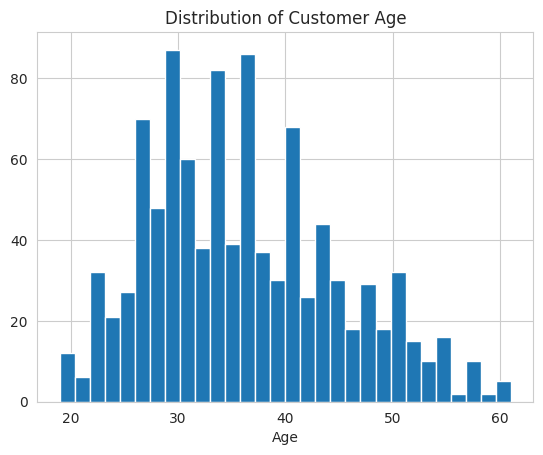

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
ad_data['Age'].hist(bins=30)
plt.xlabel('Age')
plt.title('Distribution of Customer Age')
plt.show()

This histogram shows the age distribution of the users in the dataset. Most users are between 25 and 45 years old.

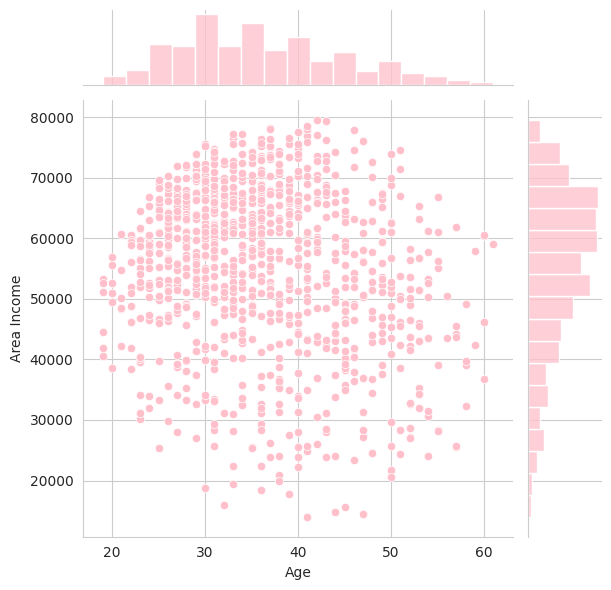

In [15]:
sns.jointplot(x='Age', y='Area Income', color='pink', data=ad_data)
plt.show()

This jointplot allows us to see the relationship between the user's age and the average income of their area. It helps identify if wealthier or older areas interact differently with ads.

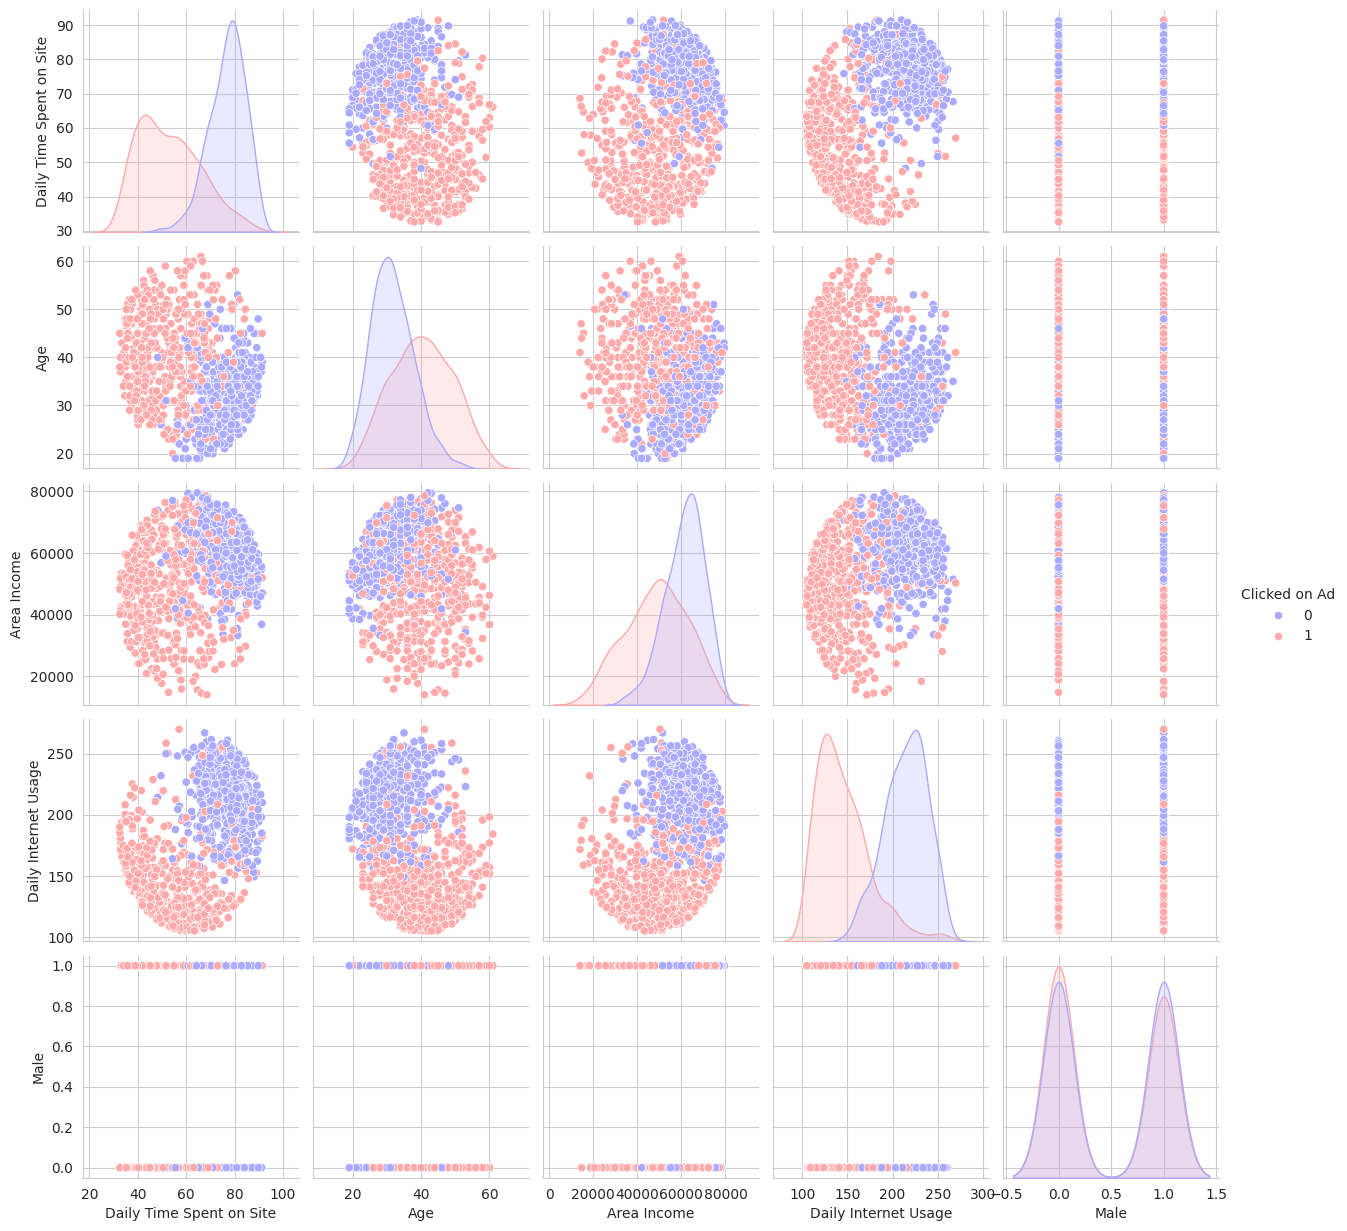

In [12]:
sns.pairplot(ad_data, hue='Clicked on Ad', palette='bwr')

Target Separation: The data points are colored by the 'Clicked on Ad' column (Blue for 'No', Red for 'Yes'). This helps us visually identify which features have a clear separation between those who clicked and those who didn't.

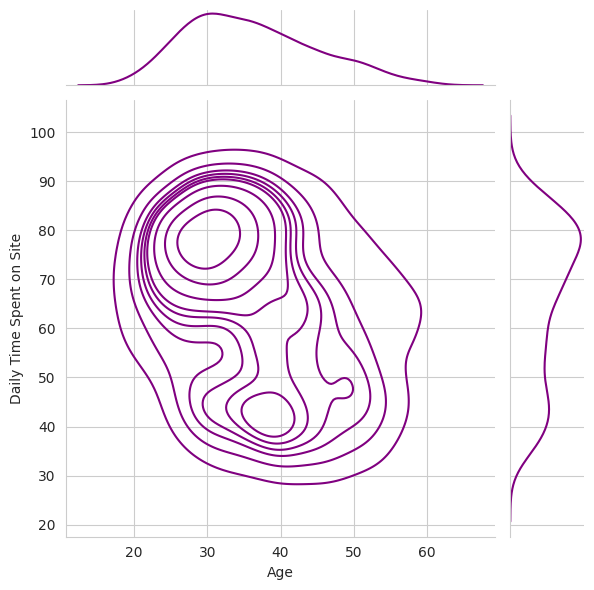

In [14]:
sns.jointplot(x='Age', y='Daily Time Spent on Site', data=ad_data, color='purple', kind='kde')

For this dataset, we can observe that there is a high density of users in their late 20s to late 30s who spend between 60 to 90 minutes daily on the site.

**Conclusion**:
In this lab, we developed a Logistic Regression model to predict whether a user will click on an advertisement. The model achieved an overall accuracy of 91%. Features like 'Daily Internet Usage' and 'Daily Time Spent on Site' were the most significant indicators of user behavior. This model can help the company target its advertisements more effectively to users who are more likely to engage.